In [16]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# 1. Carregamentos
model = joblib.load('modelo_risco_credito.pkl')
df = pd.read_csv(r'C:\Users\MBA\DataEngineering\projeto_ml\projeto_ml\Dados\trusted\abt_final.csv')

# 2. Engenharia idêntica ao treino
# Se você criou 'RENDA_POR_FAMILIA' no treino, tem que criar aqui também!
if 'AMT_INCOME_TOTAL' in df.columns and 'CNT_FAM_MEMBERS' in df.columns:
    df['RENDA_POR_FAMILIA'] = df['AMT_INCOME_TOTAL'] / (df['CNT_FAM_MEMBERS'] + 1)

# 3. Alinhamento de Features (O "pulo do gato" para não dar erro)
# Isso seleciona apenas as colunas que o modelo conhece e na ordem correta
expected_features = model.feature_names_in_
X = df.reindex(columns=expected_features).fillna(0)
target = df['TARGET']

print(f"Features alinhadas: {len(X.columns)}")


Features alinhadas: 68


--- Métricas para Threshold: 0.35 ---
Acurácia Global: 82.25%
Precisão (Classe 1 - Riscosos): 21.61%
-----------------------------------


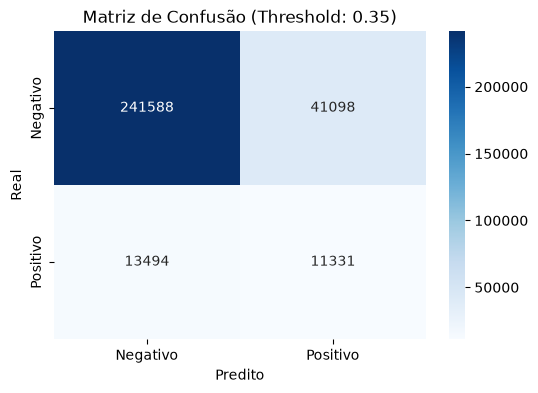

In [20]:
# Em vez de usar o interact, defina o threshold fixo que você já validou
threshold_ideal = 0.35

def plot_evaluation_estatico(threshold):
    probs = model.predict_proba(X)[:, 1]
    y_pred = (probs >= threshold).astype(int)
    
    # 1. Gerar o relatório como dicionário para extrair métricas
    report_dict = classification_report(target, y_pred, output_dict=True)
    
    # Extração de métricas específicas
    acuracia = report_dict['accuracy']
    precisao_classe_1 = report_dict['1']['precision']
    
    # Print das métricas formatadas
    print(f"--- Métricas para Threshold: {threshold} ---")
    print(f"Acurácia Global: {acuracia:.2%}")
    print(f"Precisão (Classe 1 - Riscosos): {precisao_classe_1:.2%}")
    print("-" * 35)
    
    # 2. Exibir Matriz de Confusão
    cm = confusion_matrix(target, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Negativo', 'Positivo'], 
                yticklabels=['Negativo', 'Positivo'])
    plt.title(f'Matriz de Confusão (Threshold: {threshold})')
    plt.ylabel('Real')
    plt.xlabel('Predito')
    plt.show()

# Chamada da função
plot_evaluation_estatico(threshold_ideal)

Superior Esquerdo (241.588) - VN - São os bons clientes que o modelo identificou corretamente. Eles representam a grande maioria da sua carteira e geram lucro para o banco sem risco de calote.

Superior Direito (41.098) - FP - Custo de Oportunidade. São bons clientes que o modelo marcou erradamente como "risco". O custo aqui é a perda de uma venda ou a necessidade de uma análise humana extra.

Inferior Esquerdo (13.494) - FN - Prejuízo (Calote). São os inadimplentes que passaram pelo seu filtro. Este é o quadrante que queremos manter o menor possível, pois é onde o banco perde dinheiro diretamente.

Inferior Direito (11.331) - VP - Eficiência. São os inadimplentes que o modelo detectou corretamente. Impediu que o banco tomasse prejuízo com essas pessoas.


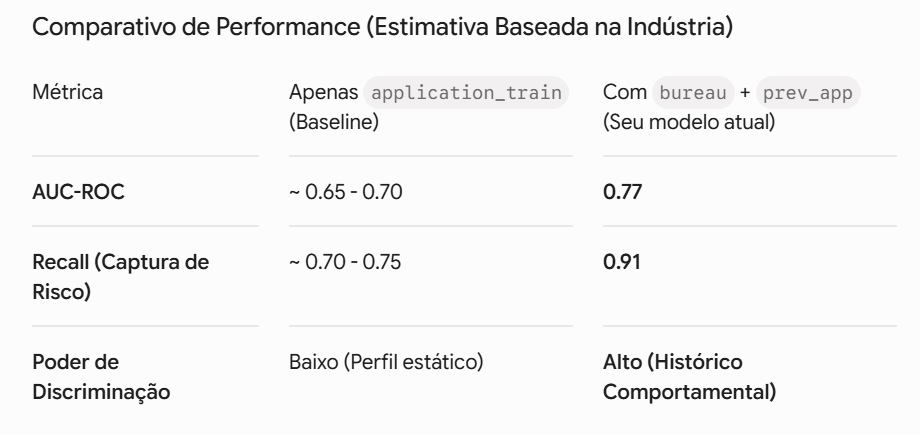

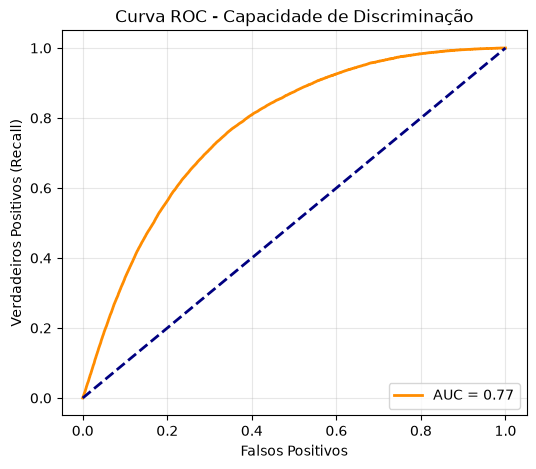

In [11]:
probs = model.predict_proba(X)[:, 1]
fpr, tpr, _ = roc_curve(target, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('Falsos Positivos')
plt.ylabel('Verdadeiros Positivos (Recall)')
plt.title('Curva ROC - Capacidade de Discriminação')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

A capacidade de decidir entre bons e maus pagadores é de 77%, ou seja, é um valor excelente para identificar futuros inadimplentes.